In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import json
import os
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
import shap
import sklearn
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

In [114]:
salary_df = pd.read_csv('../../data/salary_cleaned.csv')
print("============DATASET============:")
display(salary_df.head())

============DATASET============:


,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,company_process_time,company_industry,salary,benefit_level,company_size_level
0,2654,4,0,1,1.0,4,4,21,18.0,30,16.166886,2,1
1,5564,13,0,1,3.0,4,4,1,22.0,21,15.894952,2,1
2,249,51,0,2,1.0,4,4,0,29.0,30,15.373655,2,0
3,4975,157,0,2,2.0,4,4,22,29.0,7,15.473739,1,0
4,2891,51,0,3,2.0,0,4,37,29.0,23,16.523561,1,1


In [115]:
X = salary_df[["experience_level", "education_level", "employment_type", "career_level"]]
y = salary_df["salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X2 = salary_df.drop(columns=["salary"])
y2 = salary_df["salary"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [116]:
print("============MODEL WITH SELECTED FEATURES============:")
# Baseline models dengan default parameters (tanpa regularization manual)
# Regularization akan di-handle oleh GridSearchCV nanti
rf_model = RandomForestRegressor(random_state=42)
dt_model = DecisionTreeRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

rf_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
print(
    f"Random Forest - RMSE: {root_mean_squared_error(y_test, rf_pred):.4f} \n"
    f"Random Forest - R2: {r2_score(y_test, rf_pred):.4f} \n"
    f"Random Forest - MAE: {mean_absolute_error(y_test, rf_pred):.4f} \n"
    f"Random Forest - MAPE: {mean_absolute_percentage_error(y_test, rf_pred):.4f} \n"
)
print(
    f"Decision Tree - RMSE: {root_mean_squared_error(y_test, dt_pred):.4f} \n"
    f"Decision Tree - R2: {r2_score(y_test, dt_pred):.4f} \n"
    f"Decision Tree - MAE: {mean_absolute_error(y_test, dt_pred):.4f} \n"
    f"Decision Tree - MAPE: {mean_absolute_percentage_error(y_test, dt_pred):.4f} \n"
)
print(
    f"XGBoost - RMSE: {root_mean_squared_error(y_test, xgb_pred):.4f} \n"
    f"XGBoost - R2: {r2_score(y_test, xgb_pred):.4f} \n"
    f"XGBoost - MAE: {mean_absolute_error(y_test, xgb_pred):.4f} \n"
    f"XGBoost - MAPE: {mean_absolute_percentage_error(y_test, xgb_pred):.4f} \n"
)

============MODEL WITH SELECTED FEATURES============:
Random Forest - RMSE: 0.4971 
Random Forest - R2: 0.5166 
Random Forest - MAE: 0.3160 
Random Forest - MAPE: 0.0223 

Decision Tree - RMSE: 0.4971 
Decision Tree - R2: 0.5167 
Decision Tree - MAE: 0.3156 
Decision Tree - MAPE: 0.0221 

XGBoost - RMSE: 0.4976 
XGBoost - R2: 0.5157 
XGBoost - MAE: 0.3165 
XGBoost - MAPE: 0.0222 



In [117]:
print("============OVERFITTING CHECK============:")

# Random Forest
rf_train_pred = rf_model.predict(X_train)
rf_train_rmse = root_mean_squared_error(y_train, rf_train_pred)
rf_test_rmse = root_mean_squared_error(y_test, rf_pred)
rf_gap = abs(rf_test_rmse - rf_train_rmse)
rf_gap_pct = (rf_gap / rf_test_rmse) * 100

print(f"Random Forest:")
print(f"  Train RMSE: {rf_train_rmse:.4f}")
print(f"  Test RMSE:  {rf_test_rmse:.4f}")
print(f"  Gap:        {rf_gap:.4f} ({rf_gap_pct:.2f}%)")
if rf_gap_pct > 10:
    print(f"  ⚠️  WARNING: Possible overfitting!\n")
else:
    print(f"  ✅ Good generalization\n")

# Decision Tree
dt_train_pred = dt_model.predict(X_train)
dt_train_rmse = root_mean_squared_error(y_train, dt_train_pred)
dt_test_rmse = root_mean_squared_error(y_test, dt_pred)
dt_gap = abs(dt_test_rmse - dt_train_rmse)
dt_gap_pct = (dt_gap / dt_test_rmse) * 100

print(f"Decision Tree:")
print(f"  Train RMSE: {dt_train_rmse:.4f}")
print(f"  Test RMSE:  {dt_test_rmse:.4f}")
print(f"  Gap:        {dt_gap:.4f} ({dt_gap_pct:.2f}%)")
if dt_gap_pct > 10:
    print(f"  ⚠️  WARNING: Possible overfitting!\n")
else:
    print(f"  ✅ Good generalization\n")

# XGBoost
xgb_train_pred = xgb_model.predict(X_train)
xgb_train_rmse = root_mean_squared_error(y_train, xgb_train_pred)
xgb_test_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_gap = abs(xgb_test_rmse - xgb_train_rmse)
xgb_gap_pct = (xgb_gap / xgb_test_rmse) * 100

print(f"XGBoost:")
print(f"  Train RMSE: {xgb_train_rmse:.4f}")
print(f"  Test RMSE:  {xgb_test_rmse:.4f}")
print(f"  Gap:        {xgb_gap:.4f} ({xgb_gap_pct:.2f}%)")
if xgb_gap_pct > 10:
    print(f"  ⚠️  WARNING: Possible overfitting!")
else:
    print(f"  ✅ Good generalization")

============OVERFITTING CHECK============:
Random Forest:
  Train RMSE: 0.3857
  Test RMSE:  0.4971
  Gap:        0.1115 (22.42%)
  ⚠️  WARNING: Possible overfitting!

Decision Tree:
  Train RMSE: 0.3791
  Test RMSE:  0.4971
  Gap:        0.1180 (23.73%)
  ⚠️  WARNING: Possible overfitting!

XGBoost:
  Train RMSE: 0.3793
  Test RMSE:  0.4976
  Gap:        0.1183 (23.77%)
  ⚠️  WARNING: Possible overfitting!


### 📊 **Interpretation of Overfitting Check Results**

**If Gap > 10%:**
- The model is too complex and memorizes the training data
- **Solution:** Will be handled by GridSearchCV by finding the optimal hyperparameters
  - GridSearchCV will test various combinations of `max_depth`, `min_samples_leaf`, etc.
  - CV (Cross-Validation) ensures the model does not overfit to the training data
  - Best parameters are selected based on performance in the validation set

**Why is the baseline still the default?**
- Baseline = initial performance benchmark without tuning
- Overfitting in the baseline is **normal** and expected
- Tuning (GridSearchCV) will overcome overfitting with optimal regularization

Translated with DeepL.com (free version)

In [118]:
results = {
    "Random Forest": {
        "RMSE": root_mean_squared_error(y_test, rf_pred),
        "R2": r2_score(y_test, rf_pred),
        "MAE": mean_absolute_error(y_test, rf_pred),
        "MAPE": mean_absolute_percentage_error(y_test, rf_pred)
    },
    "Decision Tree": {
        "RMSE": root_mean_squared_error(y_test, dt_pred),
        "R2": r2_score(y_test, dt_pred),
        "MAE": mean_absolute_error(y_test, dt_pred),
        "MAPE": mean_absolute_percentage_error(y_test, dt_pred)
    },
    "XGBoost": {
        "RMSE": root_mean_squared_error(y_test, xgb_pred),
        "R2": r2_score(y_test, xgb_pred),
        "MAE": mean_absolute_error(y_test, xgb_pred),
        "MAPE": mean_absolute_percentage_error(y_test, xgb_pred)
    }
}
df_results = pd.DataFrame(results).T
print("===== METRIC RESULTS =====")
print(df_results)
ranking = df_results.copy()
# For RMSE, MAE, MAPE: lower is better → rank ascending
for metric in ["RMSE", "MAE", "MAPE"]:
    ranking[metric] = ranking[metric].rank(method="min")
# For R2: higher is better → rank descending
ranking["R2"] = ranking["R2"].rank(ascending=False, method="min")
print("\n===== RANKING =====")
print(ranking)
ranking["Total Rank"] = ranking.sum(axis=1)
print("\n===== TOTAL RANK =====")
print(ranking.sort_values("Total Rank"))
best_model = ranking["Total Rank"].idxmin()
print(f"\n🎯 Overall Best Model: {best_model}")

===== METRIC RESULTS =====
                   RMSE        R2       MAE      MAPE
Random Forest  0.497135  0.516640  0.316000  0.022308
Decision Tree  0.497124  0.516661  0.315629  0.022101
XGBoost        0.497639  0.515659  0.316461  0.022150

===== RANKING =====
               RMSE   R2  MAE  MAPE
Random Forest   2.0  2.0  2.0   3.0
Decision Tree   1.0  1.0  1.0   1.0
XGBoost         3.0  3.0  3.0   2.0

===== TOTAL RANK =====
               RMSE   R2  MAE  MAPE  Total Rank
Decision Tree   1.0  1.0  1.0   1.0         4.0
Random Forest   2.0  2.0  2.0   3.0         9.0
XGBoost         3.0  3.0  3.0   2.0        11.0

🎯 Overall Best Model: Decision Tree


In [119]:
print("============MODEL WITH ALL FEATURES============:")
rf_model2 = RandomForestRegressor(random_state=42)
dt_model2 = DecisionTreeRegressor(random_state=42)
xgb_model2 = XGBRegressor(random_state=42, objective='reg:squarederror')
rf_model2.fit(X_train2, y_train2)
dt_model2.fit(X_train2, y_train2)
xgb_model2.fit(X_train2, y_train2)
rf_pred2 = rf_model2.predict(X_test2)
dt_pred2 = dt_model2.predict(X_test2)
xgb_pred2 = xgb_model2.predict(X_test2)
print(
    f"Random Forest (All Features) - RMSE: {root_mean_squared_error(y_test2, rf_pred2):.4f} \n"
    f"Random Forest (All Features) - R2: {r2_score(y_test2, rf_pred2):.4f} \n"
    f"Random Forest (All Features) - MAE: {mean_absolute_error(y_test2, rf_pred2):.4f} \n"
    f"Random Forest (All Features) - MAPE: {mean_absolute_percentage_error(y_test2, rf_pred2):.4f}\n"
)
print(
    f"Decision Tree (All Features) - RMSE: {root_mean_squared_error(y_test2, dt_pred2):.4f} \n"
    f"Decision Tree (All Features) - R2: {r2_score(y_test2, dt_pred2):.4f} \n"
    f"Decision Tree (All Features) - MAE: {mean_absolute_error(y_test2, dt_pred2):.4f} \n"
    f"Decision Tree (All Features) - MAPE: {mean_absolute_percentage_error(y_test2, dt_pred2):.4f} \n"
)
print(
    f"XGBoost (All Features) - RMSE: {root_mean_squared_error(y_test2, xgb_pred2):.4f} \n"
    f"XGBoost (All Features) - R2: {r2_score(y_test2, xgb_pred2):.4f} \n"
    f"XGBoost (All Features) - MAE: {mean_absolute_error(y_test2, xgb_pred2):.4f} \n"
    f"XGBoost (All Features) - MAPE: {mean_absolute_percentage_error(y_test2, xgb_pred2):.4f} \n"
)

============MODEL WITH ALL FEATURES============:
Random Forest (All Features) - RMSE: 0.4290 
Random Forest (All Features) - R2: 0.6401 
Random Forest (All Features) - MAE: 0.2313 
Random Forest (All Features) - MAPE: 0.0169

Decision Tree (All Features) - RMSE: 0.5127 
Decision Tree (All Features) - R2: 0.4859 
Decision Tree (All Features) - MAE: 0.2987 
Decision Tree (All Features) - MAPE: 0.0209 

XGBoost (All Features) - RMSE: 0.4262 
XGBoost (All Features) - R2: 0.6448 
XGBoost (All Features) - MAE: 0.2319 
XGBoost (All Features) - MAPE: 0.0168 



In [120]:
results = {
    "Random Forest 2": {
        "RMSE": root_mean_squared_error(y_test2, rf_pred2),
        "R2": r2_score(y_test2, rf_pred2),
        "MAE": mean_absolute_error(y_test2, rf_pred2),
        "MAPE": mean_absolute_percentage_error(y_test2, rf_pred2)
    },
    "Decision Tree": {
        "RMSE": root_mean_squared_error(y_test2, dt_pred2),
        "R2": r2_score(y_test2, dt_pred2),
        "MAE": mean_absolute_error(y_test2, dt_pred2),
        "MAPE": mean_absolute_percentage_error(y_test2, dt_pred2)
    },
    "XGBoost": {
        "RMSE": root_mean_squared_error(y_test2, xgb_pred2),
        "R2": r2_score(y_test2, xgb_pred2),
        "MAE": mean_absolute_error(y_test2, xgb_pred2),
        "MAPE": mean_absolute_percentage_error(y_test2, xgb_pred2)
    }
}
df_results = pd.DataFrame(results).T
print("===== METRIC RESULTS =====")
print(df_results)
ranking = df_results.copy()
# For RMSE, MAE, MAPE: lower is better → rank ascending
for metric in ["RMSE", "MAE", "MAPE"]:
    ranking[metric] = ranking[metric].rank(method="min")
# For R2: higher is better → rank descending
ranking["R2"] = ranking["R2"].rank(ascending=False, method="min")
print("\n===== RANKING =====")
print(ranking)
ranking["Total Rank"] = ranking.sum(axis=1)
print("\n===== TOTAL RANK =====")
print(ranking.sort_values("Total Rank"))
best_model = ranking["Total Rank"].idxmin()
print(f"\n🎯 Overall Best Model: {best_model}")

===== METRIC RESULTS =====
                     RMSE        R2       MAE      MAPE
Random Forest 2  0.428977  0.640093  0.231323  0.016859
Decision Tree    0.512692  0.485915  0.298671  0.020942
XGBoost          0.426154  0.644815  0.231936  0.016804

===== RANKING =====
                 RMSE   R2  MAE  MAPE
Random Forest 2   2.0  2.0  1.0   2.0
Decision Tree     3.0  3.0  3.0   3.0
XGBoost           1.0  1.0  2.0   1.0

===== TOTAL RANK =====
                 RMSE   R2  MAE  MAPE  Total Rank
XGBoost           1.0  1.0  2.0   1.0         5.0
Random Forest 2   2.0  2.0  1.0   2.0         7.0
Decision Tree     3.0  3.0  3.0   3.0        12.0

🎯 Overall Best Model: XGBoost


============MODEL WITH SELECTED FEATURES============:



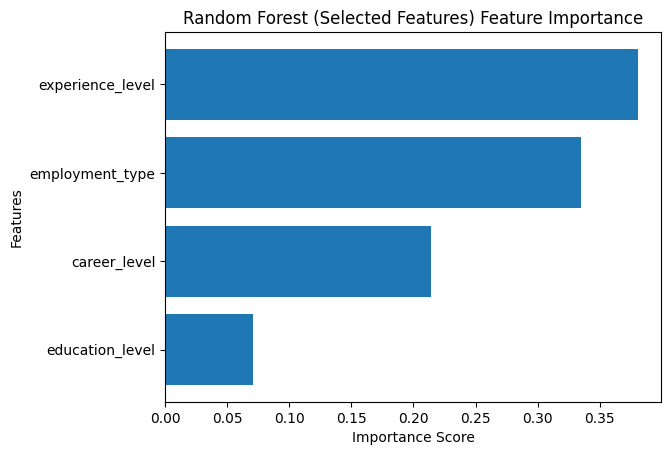

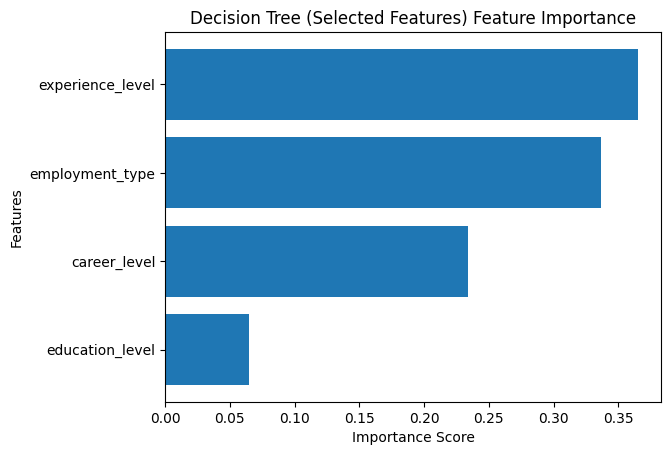

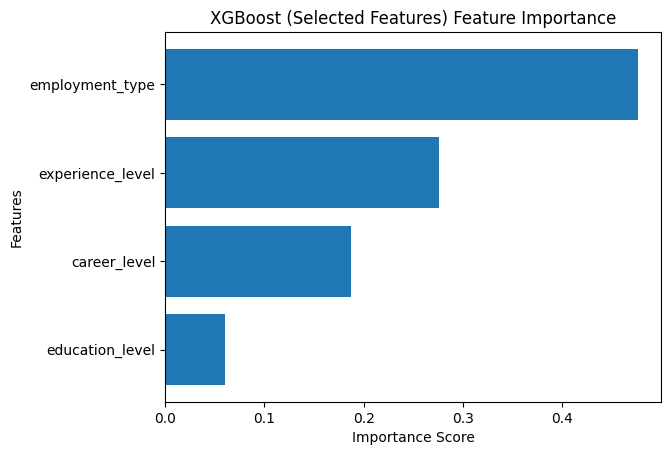

In [121]:
print("============MODEL WITH SELECTED FEATURES============:\n")
import matplotlib.pyplot as plt

def plot_feature_importance(model, model_name):
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=True)
    
    plt.figure()
    plt.barh(importance["Feature"], importance["Importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()

plot_feature_importance(rf_model, "Random Forest (Selected Features)")
plot_feature_importance(dt_model, "Decision Tree (Selected Features)")
plot_feature_importance(xgb_model, "XGBoost (Selected Features)")

============MODEL WITH ALL FEATURES============:



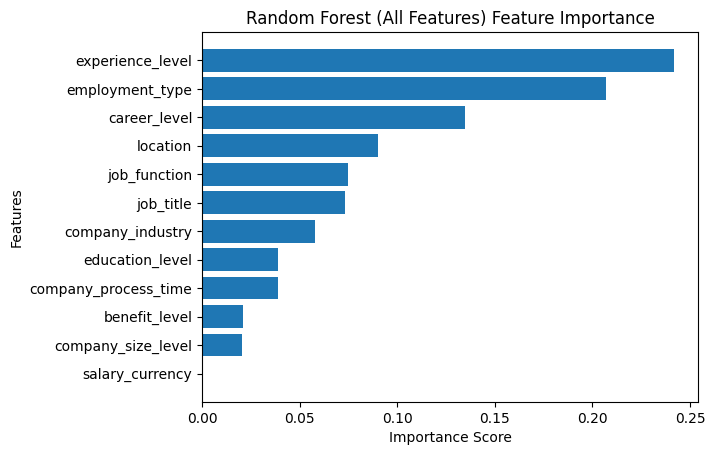

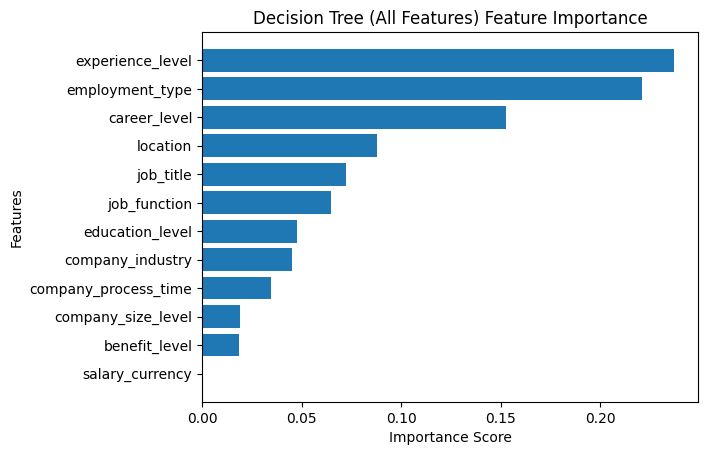

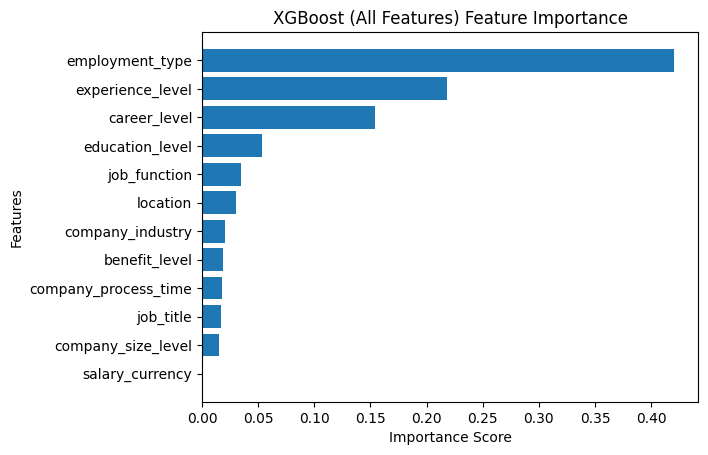

In [122]:
print("============MODEL WITH ALL FEATURES============:\n")
def plot_feature_importance(model, model_name):
    importance = pd.DataFrame({
        "Feature": X_train2.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=True)
    
    plt.figure()
    plt.barh(importance["Feature"], importance["Importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()

plot_feature_importance(rf_model2, "Random Forest (All Features)")
plot_feature_importance(dt_model2, "Decision Tree (All Features)")
plot_feature_importance(xgb_model2, "XGBoost (All Features)")

# **CONCLUSION**
So, the **conclusion** is that the best regression model using feature selection is Decision Tree from the heatmap correlation results in the exploratory data analysis (EDA) stage, and the best regression model using all features is XGBoost, where we see the important features that influence it, namely the “experience_level”, “employment_type,” “career_level,” and “education_level,” which are the same as those used by the Decision Tree model with feature selection.

What would happen if we used the shap library to see which important features influence the prediction?

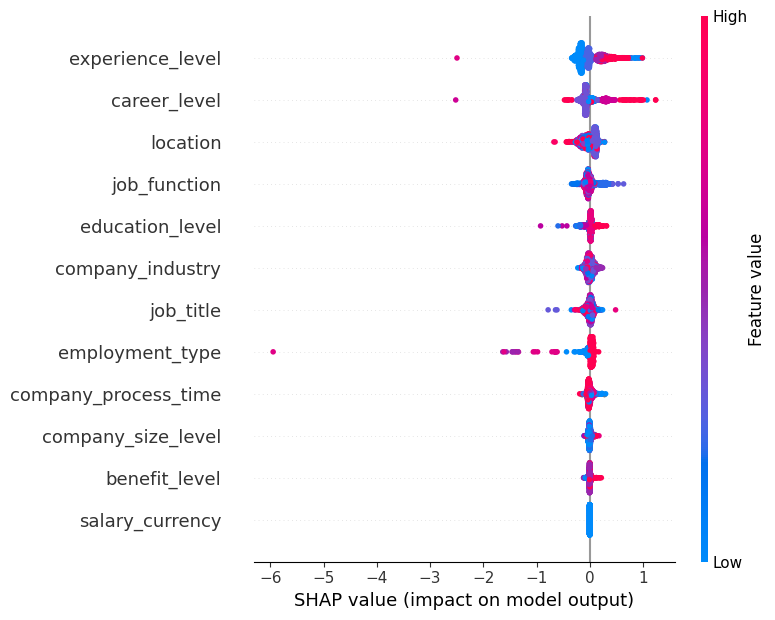

In [123]:
explainer = shap.TreeExplainer(xgb_model2)
shap_values = explainer.shap_values(X_test2)
# Summary plot (global importance)
shap.summary_plot(shap_values, X_test2)

**Explanation of results:** And sure enough, using the shap library will produce the same output.

# **HYPERPARAMETER TUNING**
What will happen if we use the ***GridSearchCV*** library to determine the best parameters for the three models using the selected features, namely “experience_level,” “employment_type,” “career_level,” and “education_level”?

In [124]:
# For Hyperparameter Tuning (Random Forest)
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    },
    refit="rmse",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF RMSE:", -rf_grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best RF RMSE: 0.42656879787262236


In [125]:
# For Hyperparameter Tuning (Decision Tree)
dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    },
    refit="rmse",
    cv=5,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)  # FIXED: X_train instead of X_train2

print("Best DT Params:", dt_grid.best_params_)
print("Best DT RMSE:", -dt_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best DT Params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best DT RMSE: 0.4228262716708815


In [126]:
# For Hyperparameter Tuning (XGBoost)
xgb_param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    xgb_param_grid,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    },
    refit="rmse",
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)  # FIXED: X_train instead of X_train2

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB RMSE:", -xgb_grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best XGB Params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
Best XGB RMSE: 0.4164263527090307


In [127]:
comparison = {
    "Random Forest": -rf_grid.best_score_,
    "Decision Tree": -dt_grid.best_score_,
    "XGBoost": -xgb_grid.best_score_
}

best_model_name = min(comparison, key=comparison.get)

print("\n===== MODEL COMPARISON (RMSE CV) =====")
print(comparison)
print("\n🎯 BEST MODEL:", best_model_name)


===== MODEL COMPARISON (RMSE CV) =====
{'Random Forest': np.float64(0.42656879787262236), 'Decision Tree': np.float64(0.4228262716708815), 'XGBoost': np.float64(0.4164263527090307)}

🎯 BEST MODEL: XGBoost


From the ***GridSearchCV*** results for the three models, the result is XGBoostregressor. Try training and predicting the features.

XGBoost - RMSE: 0.4958 
XGBoost - R2: 0.5192 
XGBoost - MAE: 0.3159 
XGBoost - MAPE: 0.0222 



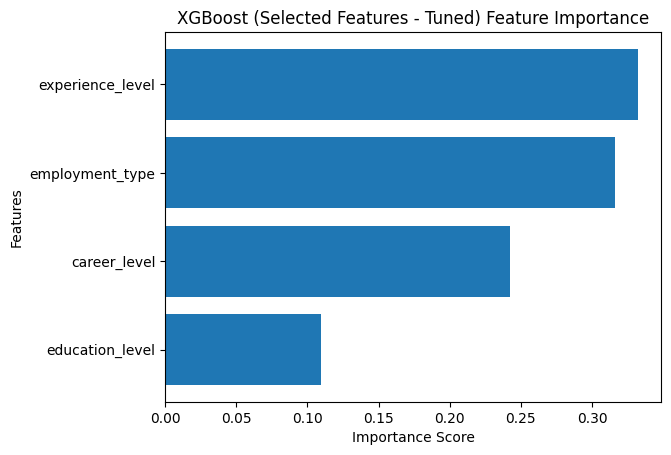

In [128]:
X3 = salary_df[["experience_level", "education_level", "employment_type", "career_level"]]
y3 = salary_df["salary"]
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)
xgb_model3 = XGBRegressor(random_state=42, colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, n_estimators=500, subsample=0.8, objective='reg:squarederror')
xgb_model3.fit(X_train3, y_train3)
xgb_pred3 = xgb_model3.predict(X_test3)
print(
    f"XGBoost - RMSE: {root_mean_squared_error(y_test3, xgb_pred3):.4f} \n"
    f"XGBoost - R2: {r2_score(y_test3, xgb_pred3):.4f} \n"
    f"XGBoost - MAE: {mean_absolute_error(y_test3, xgb_pred3):.4f} \n"
    f"XGBoost - MAPE: {mean_absolute_percentage_error(y_test3, xgb_pred3):.4f} \n"
)
def plot_feature_importance(model, model_name):
    importance = pd.DataFrame({
        "Feature": X_train3.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=True)
    
    plt.figure()
    plt.barh(importance["Feature"], importance["Importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()
plot_feature_importance(xgb_model3, "XGBoost (Selected Features - Tuned)")

============RESIDUAL ANALYSIS============:


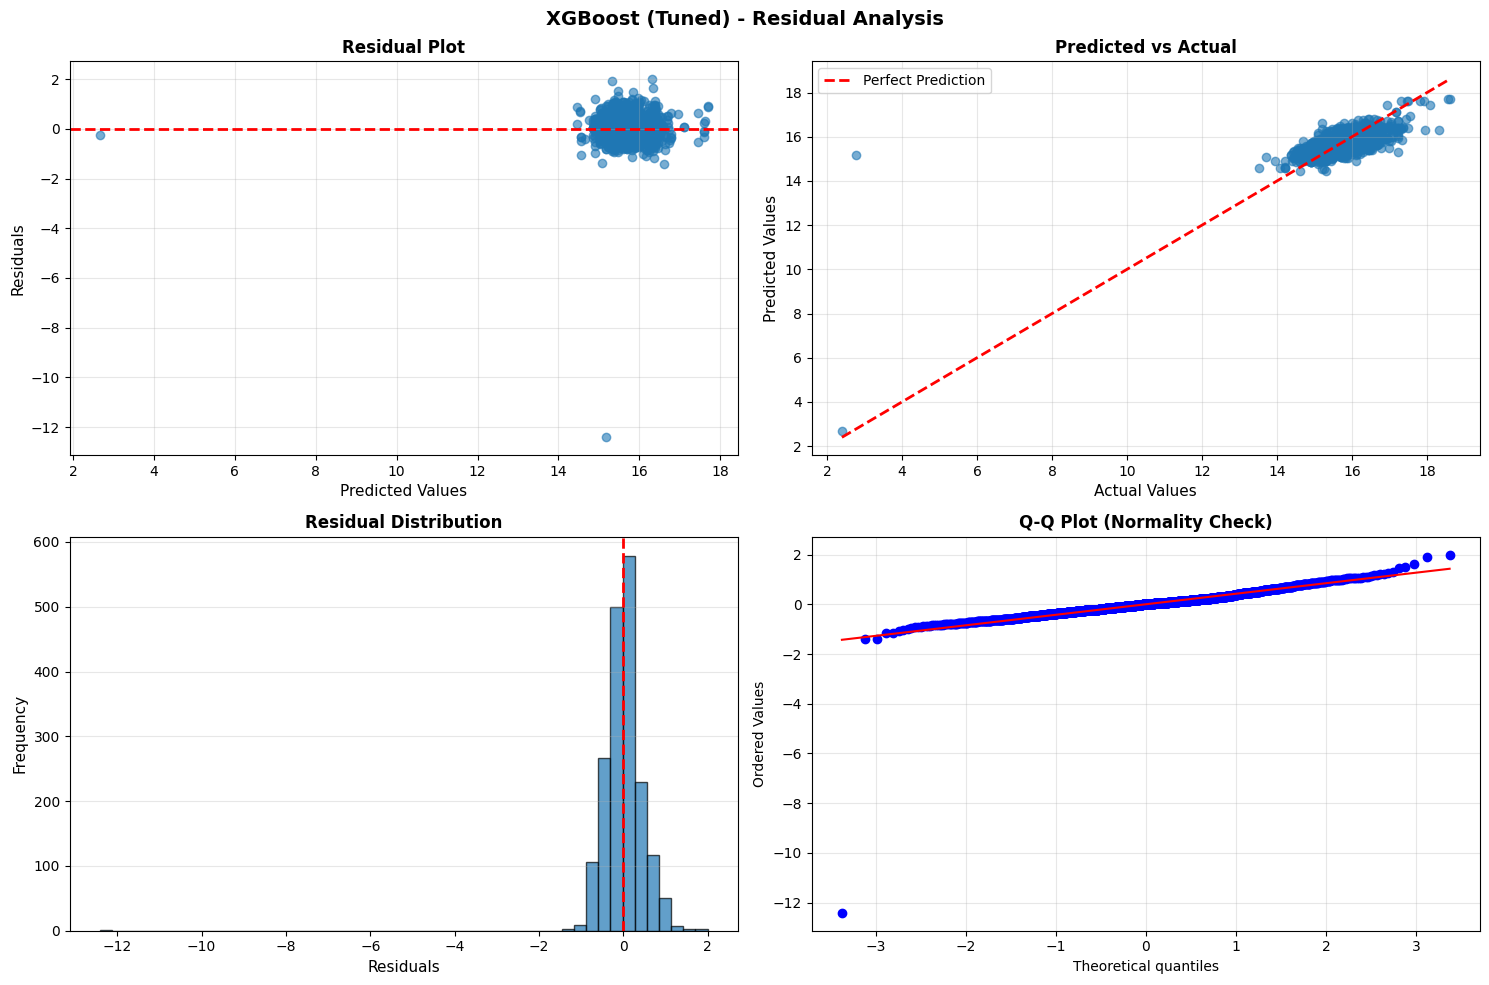

Mean Residual:   0.002182 (should be ~0)
Std Residual:    0.4959
Min Residual:    -12.4108
Max Residual:    1.9950

Shapiro-Wilk Test (Normality):
  p-value: 0.0000
  ⚠️  Residuals NOT normally distributed


In [129]:
print("============RESIDUAL ANALYSIS============:")

residuals = y_test3 - xgb_pred3

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residual Plot
axes[0, 0].scatter(xgb_pred3, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Predicted vs Actual
axes[0, 1].scatter(y_test3, xgb_pred3, alpha=0.6)
axes[0, 1].plot([y_test3.min(), y_test3.max()], [y_test3.min(), y_test3.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Values', fontsize=11)
axes[0, 1].set_ylabel('Predicted Values', fontsize=11)
axes[0, 1].set_title('Predicted vs Actual', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual Distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('XGBoost (Tuned) - Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical summary
print(f"Mean Residual:   {residuals.mean():.6f} (should be ~0)")
print(f"Std Residual:    {residuals.std():.4f}")
print(f"Min Residual:    {residuals.min():.4f}")
print(f"Max Residual:    {residuals.max():.4f}")

# Normality test
stat, p_value = stats.shapiro(residuals.sample(min(5000, len(residuals)), random_state=42))
print(f"\nShapiro-Wilk Test (Normality):")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  ⚠️  Residuals NOT normally distributed")
else:
    print(f"  ✅ Residuals approximately normal")

### 📊 ****Residual Analysis Interpretation****

**1. Residual Plot (Top Left):**
- ✅ **Ideal:** Residuals are randomly scattered around the 0 line (horizontal)
- ⚠️ **Warning:** If there is a pattern (funnel, curve), it means that the model has not captured all data patterns
- 🔍 **Outliers:** Points that are very far from 0 are bad predictions

**2. Predicted vs Actual (Top Right):**
- ✅ **Ideal:** All points are on the red line (perfect prediction)
- 📊 **Interpretation:** The closer to the red line, the more accurate the prediction
- Points above the line = underprediction, below the line = overprediction

**3. Residual Distribution (Bottom Left):**
- ✅ **Ideal:** Bell curve shape (normal distribution) centered at 0
- Mean residual should be ~0 (model is unbiased)
- If skewed → model tends to under/overpredict

**4. Q-Q Plot (Bottom Right):**
- ✅ **Ideal:** Points follow the diagonal line
- ⚠️ **Deviation at the ends:** Indicates outliers or heavy tails
- Normal distribution → residuals are random/no systematic pattern

**📌 Conclusion:**
If Shapiro-Wilk p-value < 0.05 → residuals are NOT normal (there are patterns that the model has not captured or outliers that need to be handled)

Translated with DeepL.com (free version)

In [130]:
print("============OUTLIER HANDLING============:")

# Identifikasi outliers berdasarkan residuals (threshold: 3 standard deviations)
residual_threshold = 3 * residuals.std()
outlier_mask = np.abs(residuals) > residual_threshold

print(f"Residual std: {residuals.std():.4f}")
print(f"Threshold (±3σ): ±{residual_threshold:.4f}")
print(f"Number of outliers detected: {outlier_mask.sum()} ({(outlier_mask.sum()/len(residuals)*100):.2f}%)")

# Remove outliers dari test set
X_test3_cleaned = X_test3[~outlier_mask]
y_test3_cleaned = y_test3[~outlier_mask]

print(f"\nOriginal test set size: {len(X_test3)}")
print(f"Cleaned test set size:  {len(X_test3_cleaned)}")
print(f"Removed: {outlier_mask.sum()} samples")

============OUTLIER HANDLING============:
Residual std: 0.4959
Threshold (±3σ): ±1.4878
Number of outliers detected: 5 (0.27%)

Original test set size: 1871
Cleaned test set size:  1866
Removed: 5 samples


In [131]:
print("============RE-EVALUATE MODEL (WITHOUT OUTLIERS)============:")

# Prediksi ulang dengan data clean
xgb_pred3_clean = xgb_model3.predict(X_test3_cleaned)

# Hitung metrics
rmse_clean = root_mean_squared_error(y_test3_cleaned, xgb_pred3_clean)
r2_clean = r2_score(y_test3_cleaned, xgb_pred3_clean)
mae_clean = mean_absolute_error(y_test3_cleaned, xgb_pred3_clean)
mape_clean = mean_absolute_percentage_error(y_test3_cleaned, xgb_pred3_clean)

print(f"With Outliers:")
print(f"  RMSE: {root_mean_squared_error(y_test3, xgb_pred3):.4f}")
print(f"  R²:   {r2_score(y_test3, xgb_pred3):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test3, xgb_pred3):.4f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_test3, xgb_pred3):.4f}")

print(f"\nWithout Outliers:")
print(f"  RMSE: {rmse_clean:.4f} (↓ {root_mean_squared_error(y_test3, xgb_pred3) - rmse_clean:.4f})")
print(f"  R²:   {r2_clean:.4f} (↑ {r2_clean - r2_score(y_test3, xgb_pred3):.4f})")
print(f"  MAE:  {mae_clean:.4f}")
print(f"  MAPE: {mape_clean:.4f}")

# Residual analysis untuk cleaned data
residuals_clean = y_test3_cleaned - xgb_pred3_clean
print(f"\nResidual Statistics (Cleaned):")
print(f"  Mean: {residuals_clean.mean():.6f}")
print(f"  Std:  {residuals_clean.std():.4f} (↓ {residuals.std() - residuals_clean.std():.4f})")

if rmse_clean < root_mean_squared_error(y_test3, xgb_pred3):
    print(f"\n✅ Model performs BETTER without outliers!")
else:
    print(f"\n⚠️ Outlier removal did not improve performance")

============RE-EVALUATE MODEL (WITHOUT OUTLIERS)============:
With Outliers:
  RMSE: 0.4958
  R²:   0.5192
  MAE:  0.3159
  MAPE: 0.0222

Without Outliers:
  RMSE: 0.3965 (↓ 0.0993)
  R²:   0.6213 (↑ 0.1021)
  MAE:  0.3063
  MAPE: 0.0196

Residual Statistics (Cleaned):
  Mean: 0.005068
  Std:  0.3966 (↓ 0.0994)

✅ Model performs BETTER without outliers!


In [132]:
print("============FINAL MODEL OVERFITTING CHECK (CLEANED DATA)============:")

xgb_train_pred3 = xgb_model3.predict(X_train3)
train_rmse = root_mean_squared_error(y_train3, xgb_train_pred3)
train_r2 = r2_score(y_train3, xgb_train_pred3)

xgb_pred3_clean = xgb_model3.predict(X_test3_cleaned)
test_rmse = root_mean_squared_error(y_test3_cleaned, xgb_pred3_clean)
test_r2 = r2_score(y_test3_cleaned, xgb_pred3_clean)

rmse_gap = abs(test_rmse - train_rmse)
rmse_gap_pct = (rmse_gap / test_rmse) * 100
r2_gap = abs(train_r2 - test_r2)

print(f"Training Set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Set (Cleaned - No Outliers):")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

print(f"\nGap Analysis:")
print(f"  RMSE Gap: {rmse_gap:.4f} ({rmse_gap_pct:.2f}%)")
print(f"  R² Gap:   {r2_gap:.4f}")

if rmse_gap_pct > 10 or r2_gap > 0.1:
    print(f"\n⚠️  WARNING: Possible overfitting!")
    print(f"→ Consider: more regularization or simpler model")
else:
    print(f"\n✅ GOOD: Model generalizes well!")
    print(f"→ Ready for production")

============FINAL MODEL OVERFITTING CHECK (CLEANED DATA)============:
Training Set:
  RMSE: 0.3837
  R²:   0.6388

Test Set (Cleaned - No Outliers):
  RMSE: 0.3965
  R²:   0.6213

Gap Analysis:
  RMSE Gap: 0.0128 (3.23%)
  R² Gap:   0.0175

✅ GOOD: Model generalizes well!
→ Ready for production


============FINAL FEATURE IMPORTANCE (TUNED MODEL AND CLEANED DATA)============:


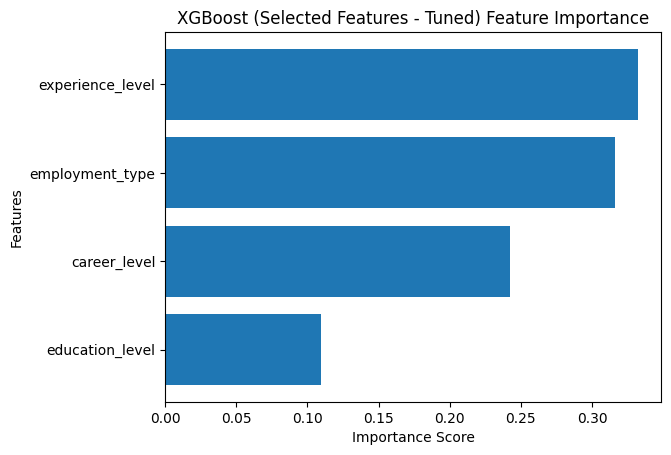

In [133]:
print("============FINAL FEATURE IMPORTANCE (TUNED MODEL AND CLEANED DATA)============:")
def plot_feature_importance(model, model_name):
    importance = pd.DataFrame({
        "Feature": X_train3.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=True)
    
    plt.figure()
    plt.barh(importance["Feature"], importance["Importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()
plot_feature_importance(xgb_model3, "XGBoost (Selected Features - Tuned)")

In [ ]:
# print("\n============SAVING FINAL MODEL============:\n")

# MODEL_DIR = "../../models"

# # Create directory if not exists
# os.makedirs(MODEL_DIR, exist_ok=True)

# # Generate timestamp
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# model_filename = f"xgboost_tuned_{timestamp}.pkl"
# model_path = os.path.join(MODEL_DIR, model_filename)

# # Save model
# joblib.dump(xgb_model3, model_path)

# # Extract hyperparameters from model
# model_params = xgb_model3.get_params()

# # Create metadata
# metadata = {
#     'model_name': 'XGBoost Tuned',
#     'timestamp': datetime.now().isoformat(),
#     'features': ["experience_level", "education_level", "employment_type", "career_level"],
#     'hyperparameters': {
#         'colsample_bytree': model_params['colsample_bytree'],
#         'gamma': model_params['gamma'],
#         'learning_rate': model_params['learning_rate'],
#         'max_depth': model_params['max_depth'],
#         'n_estimators': model_params['n_estimators'],
#         'subsample': model_params['subsample'],
#         'objective': model_params['objective'],
#         'random_state': model_params['random_state']
#     },
#     'metrics': {
#         'test_rmse': float(test_rmse),
#         'test_r2': float(test_r2),
#         'train_rmse': float(train_rmse),
#         'train_r2': float(train_r2),
#         'rmse_gap_pct': float(rmse_gap_pct)
#     },
#     'environment': {
#         'sklearn_version': sklearn.__version__,
#         'xgboost_version': xgb_model3.__class__.__module__.split('.')[0]
#     },
#     'model_file': model_filename
# }

# # Save metadata
# metadata_filename = model_filename.replace('.pkl', '_metadata.json')
# metadata_path = os.path.join(MODEL_DIR, metadata_filename)

# with open(metadata_path, 'w') as f:
#     json.dump(metadata, f, indent=4)

# print(f"✅ Model saved successfully!")
# print(f"   📦 Model:    {model_path}")
# print(f"   📄 Metadata: {metadata_path}")
# print(f"\n   Test RMSE: {test_rmse:.4f}")
# print(f"   Test R²:   {test_r2:.4f}")

# # Test loading
# loaded_model = joblib.load(model_path)
# test_pred = loaded_model.predict(X_test3[:5])
# print(f"\n✅ Model loading test successful!")
# print(f"   Sample predictions: {test_pred[:5]}")


============SAVING FINAL MODEL============:

✅ Model saved successfully!
   📦 Model:    ../../models\xgboost_tuned_20260216_204341.pkl
   📄 Metadata: ../../models\xgboost_tuned_20260216_204341_metadata.json

   Test RMSE: 0.3965
   Test R²:   0.6213



✅ Model loading test successful!
   Sample predictions: [15.978772 15.234866 15.740939 15.380235 15.234866]
